In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [3]:
import torch.nn as nn
import torch.optim as optim

In [4]:
df = pd.read_csv("MNIST/mnist_train.csv")

In [5]:
df.sample(5)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
39377,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
49222,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7299,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
26708,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
25792,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
y = df["label"]
x = df.iloc[:,1:]
x = x


In [20]:
x.sample(5)

,22x11,22x3,8x14,23x22,7x7,8x18,16x10,10x8,22x6,8x9,...,17x19,5x10,22x27,1x21,26x1,3x16,4x23,10x19,16x16,4x19
16170,0,0,253,0,0,94,112,207,0,189,...,253,0,0,0,0,0,0,246,0,0
25875,0,0,0,0,0,0,236,0,0,0,...,184,0,0,0,0,0,0,253,198,0
56160,0,0,252,0,0,212,0,0,0,253,...,123,0,0,0,0,0,0,253,41,0
55307,108,0,237,0,0,0,254,0,0,0,...,171,0,0,0,0,58,0,0,192,0
43827,0,0,59,0,0,247,118,0,0,0,...,254,0,0,0,0,0,0,174,0,0


In [8]:
y.sample(5)

32652    3
30535    1
2664     2
10922    1
9535     7
Name: label, dtype: int64

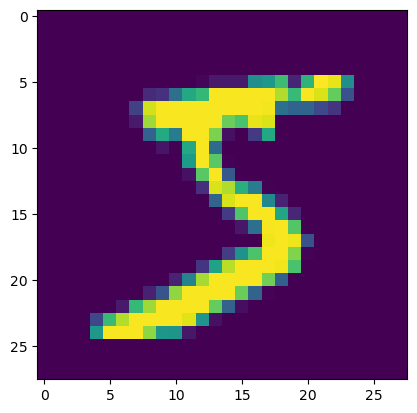

In [9]:
row1 = x.iloc[0].values
img = row1.reshape(28,28)

plt.imshow(img)
# the first image we had was the image of the digit 5.

In [10]:
x = x.sample(frac=1,axis=1,random_state=42)

In [11]:
x.sample(5)

,22x11,22x3,8x14,23x22,7x7,8x18,16x10,10x8,22x6,8x9,...,17x19,5x10,22x27,1x21,26x1,3x16,4x23,10x19,16x16,4x19
3388,0,0,0,0,0,252,248,0,0,0,...,0,0,0,0,0,0,0,254,23,0
39939,71,0,0,0,0,253,0,0,0,83,...,0,0,0,0,0,0,0,35,41,0
7162,0,0,204,0,223,0,0,0,0,158,...,252,0,0,0,0,0,0,0,0,0
145,253,0,0,0,0,0,98,0,0,0,...,0,0,0,0,0,0,0,253,47,0
37589,249,0,6,0,0,0,0,0,0,56,...,73,0,0,0,0,0,0,0,252,0


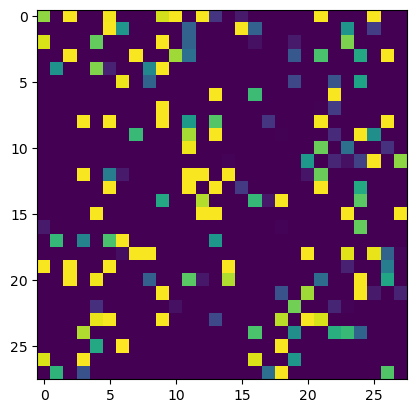

In [12]:
row1 = x.iloc[0].values
img = row1.reshape(28,28)

plt.imshow(img)
# clearly we have lost the spatial information that tells us that the image was of the digit 5.

In [13]:
#using the same FCNN that we had used for the part1 of the question.

class FCNN(nn.Module): # inherit from nn.Module
    def __init__(self):
        super().__init__()
        # define the structure of each layer
        self.input = nn.Linear(28*28, 128) 
        self.h1 = nn.Linear(128, 128)
        self.h2 = nn.Linear(128, 128)
        self.out = nn.Linear(128, 10)
        
    # the forward pass into the model
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.input(x))
        x = torch.relu(self.h1(x))
        x = torch.relu(self.h2(x))
        x = self.out(x)
        return x
    
    # for predicting the digit
    def predict(self, x):
        with torch.no_grad(): # disable gradient tracking during inference
            logits = self(x) # get raw class scores (logits) 
            predictions = torch.argmax(logits, dim=1) # select the one with highest logit
            return predictions

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FCNN().to(device) # initializing the model

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [37]:
X = torch.tensor(x.values, dtype=torch.float32).to(device)   # shape: (N, 784)
Y = torch.tensor(y.values, dtype=torch.long).to(device)      # shape: (N,)

df2 = pd.read_csv("MNIST/mnist_test.csv")
X_test = df2.iloc[:,1:]
Y_test = df2["label"]

X_test = X_test.sample(frac=1,axis=1,random_state=42)

X_test = torch.tensor(X_test.values, dtype=torch.float32).to(device)   # shape: (N, 784)
Y_test = torch.tensor(Y_test.values, dtype=torch.long).to(device)      # shape: (N,)

In [38]:
lossHistory = []
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, Y)
    loss.backward()
    optimizer.step()
    lossHistory.append(loss.item())
    # print(f"Epoch {epoch + 1}, Loss={loss.item():.4f}")



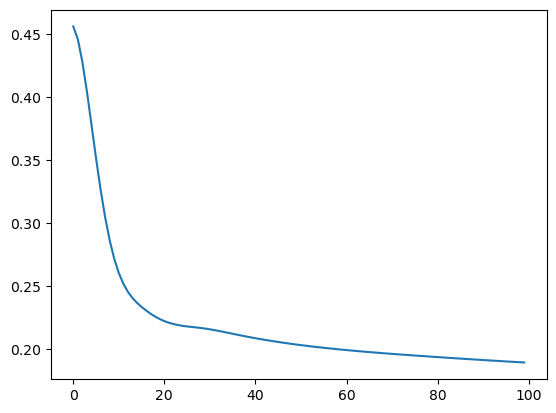

In [39]:
plt.plot(lossHistory)

In [40]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    outputs = model(X)                 # X: (N, 784)
    predictions = torch.argmax(outputs, dim=1)

    total = Y.size(0)
    correct = (predictions == Y).sum().item()

accuracy = 100 * correct / total
print(f"Train Accuracy: {accuracy:.2f}%")


Train Accuracy: 95.03%


In [ ]:
model.eval()
correct = 0
total = 0


with torch.no_grad():
    outputs = model(X_test)            # (N_test, 784)
    predictions = torch.argmax(outputs, dim=1)

    total = Y_test.size(0)
    correct = (predictions == Y_test).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 94.01%


In [50]:
X_scaled = (X - 128)/128
X_test_scaled = (X_test - 128)/128

In [51]:
lossHistory = []
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_scaled)
    loss = criterion(outputs, Y)
    loss.backward()
    optimizer.step()
    lossHistory.append(loss.item())
    # print(f"Epoch {epoch + 1}, Loss={loss.item():.4f}")


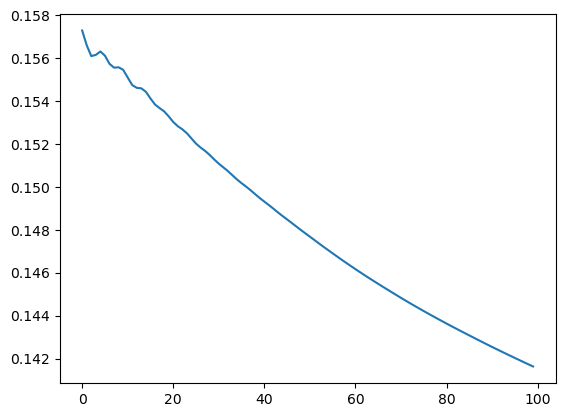

In [52]:
plt.plot(lossHistory)

In [53]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    outputs = model(X_scaled)                 # X: (N, 784)
    predictions = torch.argmax(outputs, dim=1)

    total = Y.size(0)
    correct = (predictions == Y).sum().item()

accuracy = 100 * correct / total
print(f"Train Accuracy: {accuracy:.2f}%")


correct = 0
total = 0

with torch.no_grad():
    outputs = model(X_test_scaled)            # (N_test, 784)
    predictions = torch.argmax(outputs, dim=1)

    total = Y_test.size(0)
    correct = (predictions == Y_test).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


Train Accuracy: 95.68%
Test Accuracy: 95.56%


In [54]:
X_scaled = X * 10
X_test_scaled = X_test * 10

In [55]:
lossHistory = []
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_scaled)
    loss = criterion(outputs, Y)
    loss.backward()
    optimizer.step()
    lossHistory.append(loss.item())
    # print(f"Epoch {epoch + 1}, Loss={loss.item():.4f}")


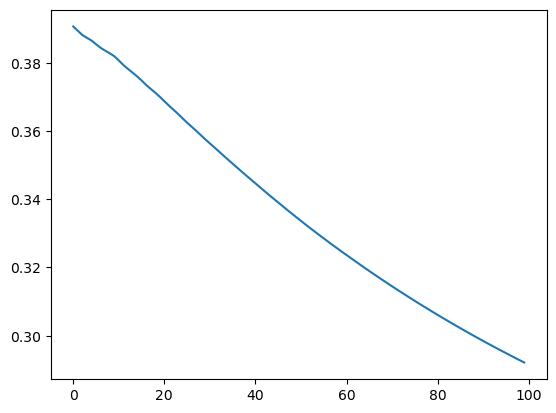

In [56]:
plt.plot(lossHistory)

In [57]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    outputs = model(X_scaled)                 # X: (N, 784)
    predictions = torch.argmax(outputs, dim=1)

    total = Y.size(0)
    correct = (predictions == Y).sum().item()

accuracy = 100 * correct / total
print(f"Train Accuracy: {accuracy:.2f}%")


correct = 0
total = 0

with torch.no_grad():
    outputs = model(X_test_scaled)            # (N_test, 784)
    predictions = torch.argmax(outputs, dim=1)

    total = Y_test.size(0)
    correct = (predictions == Y_test).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


Train Accuracy: 93.94%
Test Accuracy: 92.53%
